In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the Placement Dataset
df = pd.read_csv('placement.csv')
# Top-5 row of the Dataset
df.head(5)

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


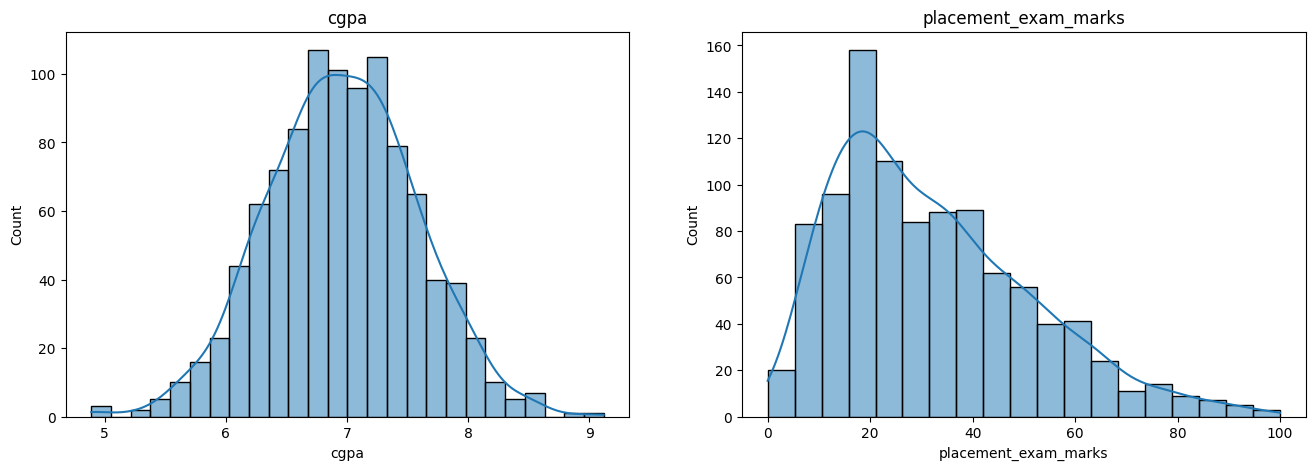

In [5]:
plt.figure(figsize=(16,5))

# plot-1 
plt.subplot(1,2,1)
sns.histplot(data=df['cgpa'], kde=True)
plt.title('cgpa')

# plot-2
plt.subplot(1,2,2)
sns.histplot(data=df['placement_exam_marks'], kde=True)
plt.title('placement_exam_marks')

# show the plot-area
plt.show()

In [8]:
# Describe the 'df['placement_exam_marks']'
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='Density'>

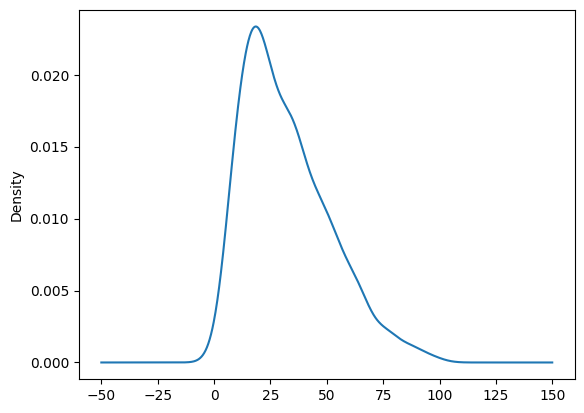

In [10]:
# There are two approaches to deal with outliers.
# 1. trimming: Deletion of rows
# 2. clipping

# Plot graph using the pandas
df['placement_exam_marks'].plot(kind='kde')

<Axes: xlabel='placement_exam_marks'>

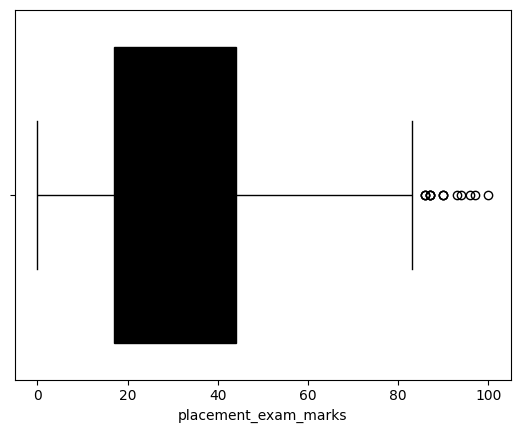

In [14]:
# Box-plot
sns.boxplot(data = df['placement_exam_marks'], orient="h", color='black')

In [16]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

# print the percentile
percentile25, percentile75

(np.float64(17.0), np.float64(44.0))

In [18]:
# Now, Interquertile Range
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [21]:
upper_lmt = percentile75 + 1.5*iqr
lower_lmt = percentile25 - 1.5*iqr

# print() the both the limit
print("Upper limit: ", upper_lmt)
print("lower limit: ", lower_lmt)

Upper limit:  84.5
lower limit:  -23.5


In [24]:
# Outliers Removed
df[df['placement_exam_marks'] < upper_lmt]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


## *Trimming*

In [25]:
new_df = df[df['placement_exam_marks'] < upper_lmt]

In [27]:
new_df.shape

(985, 3)

<Axes: xlabel='placement_exam_marks'>

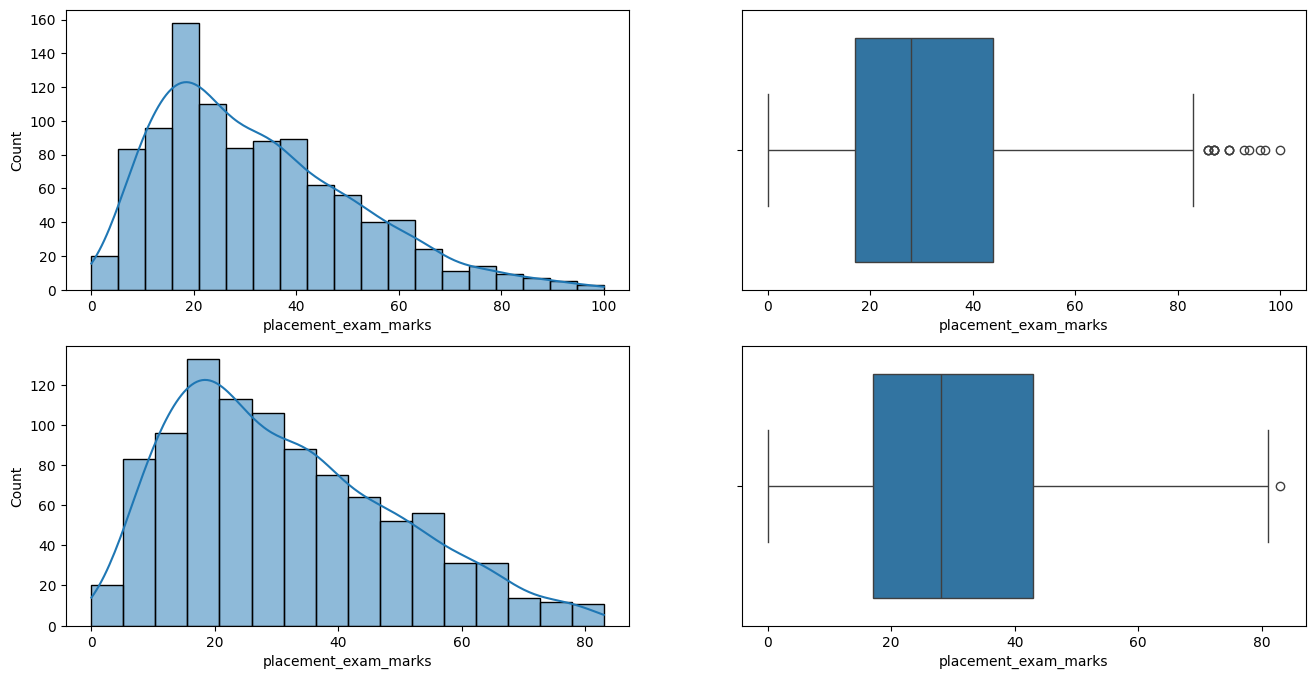

In [30]:
# Comparing

plt.figure(figsize=(16, 8))
# plot-1
plt.subplot(2,2,1)
sns.histplot(data=df['placement_exam_marks'], kde=True)
# plot-2
plt.subplot(2,2,2)
sns.boxplot(data=df['placement_exam_marks'], orient="h")
# plot-3
plt.subplot(2,2,3)
sns.histplot(data=new_df['placement_exam_marks'], kde=True, )
# plot-4
plt.subplot(2,2,4)
sns.boxplot(data=new_df['placement_exam_marks'], orient="h")

## *Capping Method*

In [33]:
# craete a Copy of Dataset
new_df_cap = df.copy()

# Replacing with teh existence columns.
# Using np.where([condition_],[If_True], [if_False])
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_lmt,
    upper_lmt,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_lmt,
        lower_lmt,
        new_df_cap['placement_exam_marks']
    )
)

In [34]:
new_df_cap.shape

(1000, 3)